In [8]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
import os
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

In [9]:
# =========================================================
# 1. SETTINGS & PATHS
# =========================================================
train_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
test_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10

# Check Dataset
print("Train Exists:", os.path.exists(train_dir))
print("Test Exists:", os.path.exists(test_dir))

Train Exists: True
Test Exists: True


In [10]:
# =========================================================
# 2. DATA AUGMENTATION & LOADERS
# =========================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Standardize Class Names
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Target Classes:", class_names)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Target Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


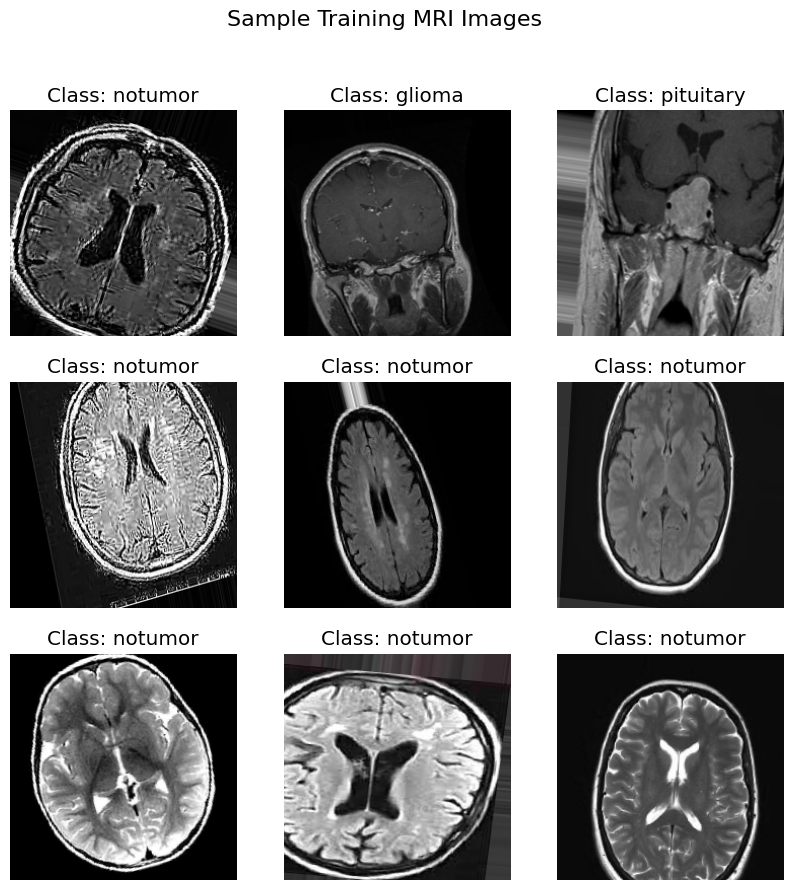

In [11]:
# =========================================================
# 3. SHOW SAMPLE MRI IMAGES
# =========================================================
def show_sample_batch(generator):
    x_batch, y_batch = next(generator)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(x_batch[i]) 
        plt.title(f"Class: {class_names[np.argmax(y_batch[i])]}")
        plt.axis("off")
    plt.suptitle("Sample Training MRI Images", fontsize=16)
    plt.show()

show_sample_batch(train_generator)

In [12]:
# =========================================================
# 4. MODEL BUILDING FUNCTION
# =========================================================
def build_model(base_model):
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(len(class_names), activation='softmax')(x)
    model = Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [13]:
# =========================================================
# 5. TRAINING PHASE (ResNet, MobileNet, VGG16)
# =========================================================
models_dict = {
    "ResNet50V2": tf.keras.applications.ResNet50V2(include_top=False, weights='imagenet', input_shape=(224,224,3)),
    "MobileNetV2": tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(224,224,3)),
    "VGG16": tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))
}

In [14]:
results = []
histories = {}
trained_models = {}
best_accuracy = 0
best_model = None
best_model_name = ""

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)

for name, base_model in models_dict.items():
    print(f"\n--- Training {name} ---")
    model = build_model(base_model)
    
    checkpoint = ModelCheckpoint(f"{name}.keras", monitor="val_accuracy", save_best_only=True, verbose=1)

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=[early_stop, reduce_lr, checkpoint]
    )

    histories[name] = history.history
    trained_models[name] = model


--- Training ResNet50V2 ---
Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5544 - loss: 1.1943
Epoch 1: val_accuracy improved from -inf to 0.78812, saving model to ResNet50V2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 105s 271ms/step - accuracy: 0.5547 - loss: 1.1935 - val_accuracy: 0.7881 - val_loss: 0.5853 - learning_rate: 1.0000e-04
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7869 - loss: 0.5802
Epoch 2: val_accuracy improved from 0.78812 to 0.82812, saving model to ResNet50V2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 83s 238ms/step - accuracy: 0.7869 - loss: 0.5801 - val_accuracy: 0.8281 - val_loss: 0.5261 - learning_rate: 1.0000e-04
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8157 - loss: 0.5061
Epoch 3: val_accuracy improved from 0.82812 to 0.84188, saving model to ResNet50V2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 81s 232ms/step - accuracy: 0.8158 - loss: 0.5061 - val_accuracy: 0.8419 - val_loss: 0.4974 - learning_rate: 1.0000e-0

In [18]:
#  Evaluation Block

eval_model = load_model(f"{name}.keras")
loss, accuracy = eval_model.evaluate(val_generator, verbose=0)

accuracy *= 100
results.append([name, accuracy])

if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_model = eval_model
    best_model_name = name

print(f"\nWinner: {best_model_name} with {best_accuracy:.2f}% accuracy")

best_model.save("brain_tumor_best_model.keras")


Winner: VGG16 with 81.81% accuracy



Final Comparison Table:
   Model   Accuracy
0  VGG16  81.812501


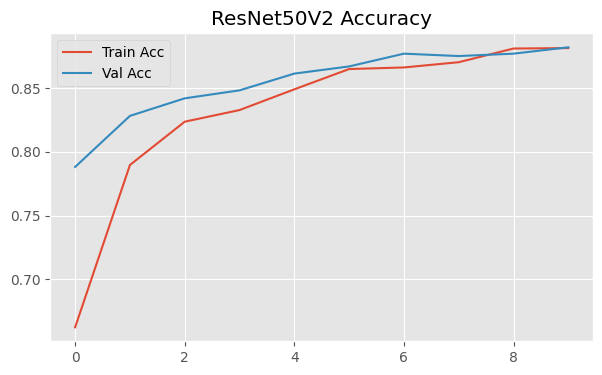

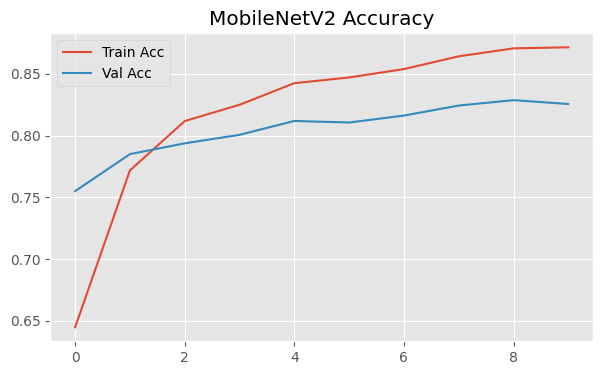

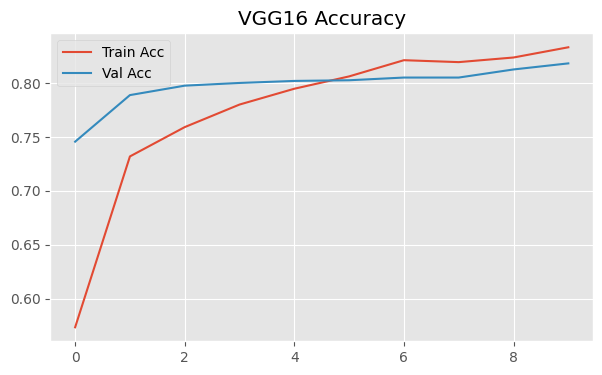

In [19]:
# =========================================================
# 6. GRAPHS & PERFORMANCE METRICS
# =========================================================
comparison = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nFinal Comparison Table:")
print(comparison)

plt.style.use('ggplot')
for model_name in histories:
    plt.figure(figsize=(7, 4))
    plt.plot(histories[model_name]['accuracy'], label='Train Acc')
    plt.plot(histories[model_name]['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    plt.show()


Classification Report : ResNet50V2

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step
              precision    recall  f1-score   support

      glioma       0.93      0.74      0.83       400
  meningioma       0.80      0.83      0.81       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.90      0.96      0.93       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



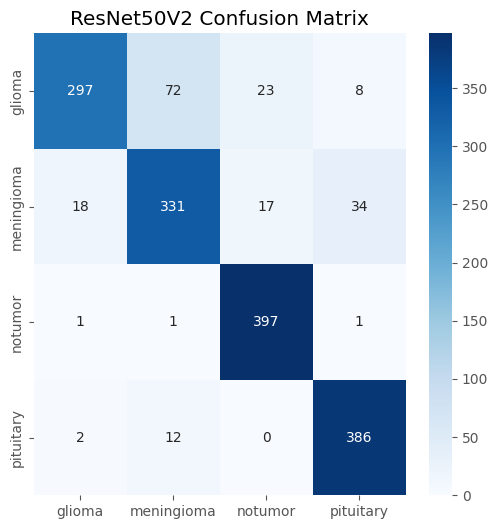


Classification Report : MobileNetV2

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step
              precision    recall  f1-score   support

      glioma       0.93      0.67      0.78       400
  meningioma       0.78      0.67      0.72       400
     notumor       0.88      0.98      0.93       400
   pituitary       0.76      0.99      0.86       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.82      1600
weighted avg       0.84      0.83      0.82      1600



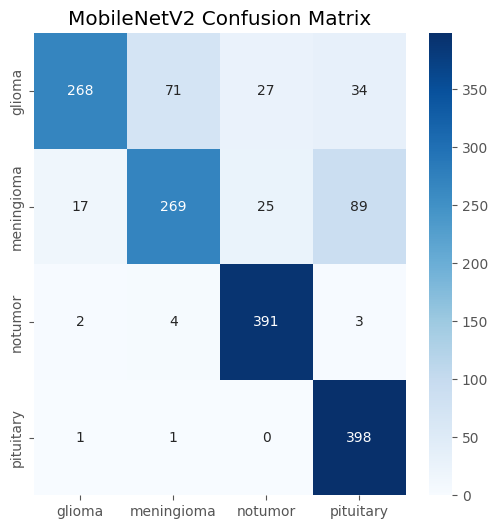


Classification Report : VGG16

100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step
              precision    recall  f1-score   support

      glioma       0.92      0.61      0.74       400
  meningioma       0.76      0.68      0.72       400
     notumor       0.82      0.99      0.90       400
   pituitary       0.79      0.99      0.88       400

    accuracy                           0.82      1600
   macro avg       0.83      0.82      0.81      1600
weighted avg       0.83      0.82      0.81      1600



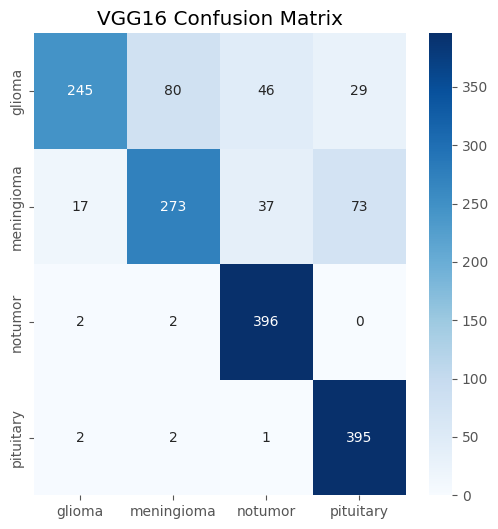

In [20]:
# Reports & Confusion Matrices
for name, model in trained_models.items():
    print(f"\nClassification Report : {name}\n")
    y_pred = np.argmax(model.predict(val_generator), axis=1)
    y_true = val_generator.classes
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [21]:
# =========================================================
# 7. PREDICTION ON ALL 4 CLASSES
# =========================================================
def predict_external_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array)
    predicted_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.title(f"Pred: {class_names[predicted_idx]} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


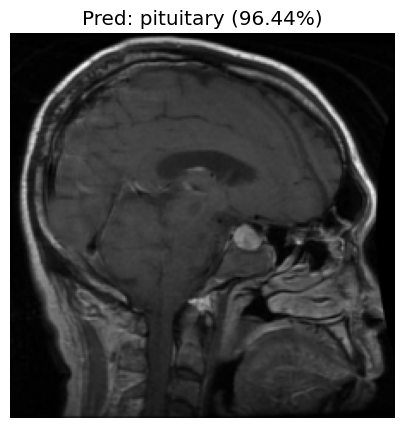

In [22]:
# Pick one sample from test folder for demonstration
sample_path = os.path.join(test_dir, os.listdir(test_dir)[0], os.listdir(os.path.join(test_dir, os.listdir(test_dir)[0]))[0])
predict_external_image(sample_path)

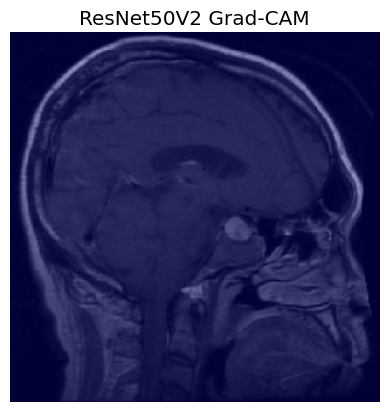

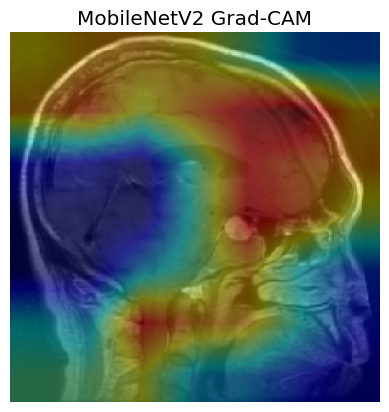

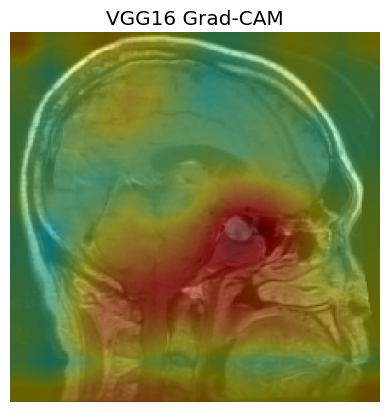

In [27]:
# =========================================================
# 8. GRAD-CAM VISUALIZATION
# =========================================================
LAST_CONV_LAYERS = {"ResNet50V2": "conv5_block3_out", "MobileNetV2": "Conv_1", "VGG16": "block5_conv3"}

def get_gradcam_models(model, name):
    backbone = next(l for l in model.layers if name.lower() in l.name.lower())
    conv_out = backbone.get_layer(LAST_CONV_LAYERS[name]).output
    conv_m = Model(inputs=backbone.input, outputs=conv_out)
    
    c_in = tf.keras.Input(shape=conv_out.shape[1:])
    x = c_in
    found = False
    for l in model.layers:
        if l == backbone: found = True; continue
        if found: x = l(x)
    return conv_m, Model(inputs=c_in, outputs=x)

def run_gradcam(model, name, path):
    img = image.load_img(path, target_size=(224, 224))
    img_arr = np.expand_dims(image.img_to_array(img)/255.0, axis=0)
    conv_m, class_m = get_gradcam_models(model, name)
    
    with tf.GradientTape() as tape:
        c_out = conv_m(img_arr, training=False)
        tape.watch(c_out)
        preds = class_m(c_out, training=False)
        score = preds[:, tf.argmax(preds[0])]

    grads = tape.gradient(score, c_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.maximum(tf.reduce_sum(c_out[0] * pooled, axis=-1), 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    # Overlay
    orig = np.array(img)
    heatmap_c = cv2.applyColorMap(np.uint8(255 * cv2.resize(heatmap.numpy(), (224,224))), cv2.COLORMAP_JET)
    res = cv2.addWeighted(orig, 0.6, heatmap_c, 0.4, 0)
    
    plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
    plt.title(f"{name} Grad-CAM")
    plt.axis("off")
    plt.show()

for name in trained_models:
    run_gradcam(trained_models[name], name, sample_path)


Model Comparison Table

         Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  \
0   ResNet50V2         88.19          88.45       88.19         87.96   
1  MobileNetV2         82.88          83.81       82.88         82.26   
2        VGG16         81.81          82.64       81.81         80.94   

    Grad-CAM  
0  Generated  
1  Generated  
2  Generated  


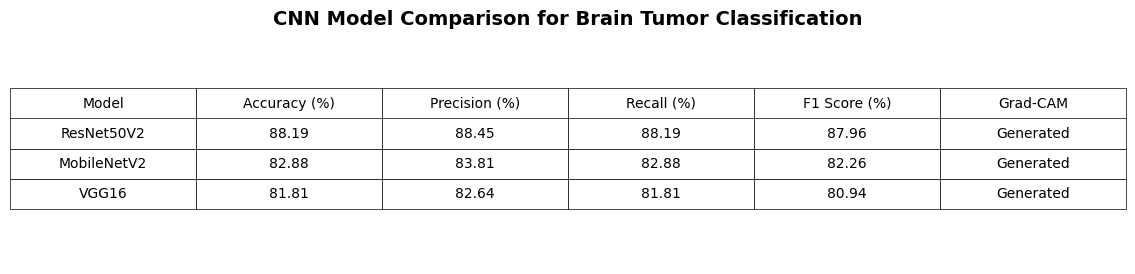

In [29]:
# =========================================================
# GENERATE COMPARISON TABLE
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison_rows = []

for name, model in trained_models.items():

    
    # Predictions
    y_pred_probs = model.predict(
        val_generator,
        verbose=0
    )

    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = val_generator.classes

    # Metrics
    accuracy = accuracy_score(
        y_true,
        y_pred
    ) * 100

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    ) * 100

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    ) * 100

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    ) * 100

    # Add row
    comparison_rows.append([

        name,

        round(accuracy, 2),

        round(precision, 2),

        round(recall, 2),

        round(f1, 2),

        "Generated"
    ])

# =========================================================
# CREATE DATAFRAME
# =========================================================

comparison_df = pd.DataFrame(

    comparison_rows,

    columns=[

        "Model",

        "Accuracy (%)",

        "Precision (%)",

        "Recall (%)",

        "F1 Score (%)",

        "Grad-CAM"
    ]
)

# =========================================================
# PRINT TABLE
# =========================================================

print("\nModel Comparison Table\n")

print(comparison_df)

# =========================================================
# BEAUTIFUL TABLE VISUALIZATION
# =========================================================

plt.figure(figsize=(12,3))

plt.axis('off')

table = plt.table(

    cellText=comparison_df.values,

    colLabels=comparison_df.columns,

    cellLoc='center',

    loc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1.2, 1.8)

plt.title(

    "CNN Model Comparison for Brain Tumor Classification",

    fontsize=14,

    fontweight='bold'
)

plt.show()